In [ ]:
from recsys_common import *

configure_notebook()
print("Shared imports loaded from recsys_common.py")

Libraries loaded successfully.


### 2.2 Data source

In [2]:
# os.makedirs("/root/.kaggle", exist_ok=True)
# !cp kaggle.json /root/.kaggle/
# !chmod 600 /root/.kaggle/kaggle.json

Download our dataset from kaggle

In [ ]:
zip_path = "amazon-product-reviews.zip"

if not os.path.exists(zip_path):
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", "arhamrumi/amazon-product-reviews"],
        check=True
    )
else:
    print(f"{zip_path} already exists, skipping download.")

Dataset URL: https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews
License(s): CC0-1.0


 99%|█████████▊| 113M/115M [00:25<00:00, 5.36MB/s] 

100%|██████████| 115M/115M [00:25<00:00, 4.65MB/s]


In [ ]:
zip_path = "amazon-product-reviews.zip"
csv_path = "Reviews.csv"

if not os.path.exists(csv_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    print("Extracted successfully.")
else:
    print(f"{csv_path} already exists, skipping extraction.")

Extracted successfully.


### 2.3 Dataset structure


In [5]:
# !ls

In [6]:
df = pd.read_csv("Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The fl...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Data types:
Id                        int64
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int64
HelpfulnessDenominator    int64
Score                     int64
Time                      int64
Summary                     str
Text                        str
dtype: object

Missing values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [8]:
n_reviews = len(df)
n_users = df["UserId"].nunique()
n_products = df["ProductId"].nunique()

print(f"Number of reviews: {n_reviews:,}")
print(f"Number of unique users: {n_users:,}")
print(f"Number of unique products: {n_products:,}")

sparsity = 1 - (n_reviews / (n_users * n_products))
print(f"Approximate user-item sparsity: {sparsity:.6f}")

Number of reviews: 568,454
Number of unique users: 256,059
Number of unique products: 74,258
Approximate user-item sparsity: 0.999970


Before building any recommender system, we need to understand how users interact with products and how reliable the data is. 

In this dataset, each row is a user review for a product including a rating and some text. Based on the dataset characterisitcs, we can say that the data is suitable to build the following different recommendation systems:
- **Collaborative filtering**: The dataset explicitly has a user item interaction matrix through `UserId`, `ProductId` and `Score`. Also, since it has many user/items and high sparsity, it makes it suitable for CF.
- **Content-based recommendation**: The dataset also contains `Summary`and `Text` which gives description of products and user opinions. 
- **Hybrid approaches**: Since we have both interaction data and content for each review, we can combine them. This can help us deal with sparce data and new users or products while still capturing how users behave and what products are actually like.

## **3. Data Preparation and Feature Engineering**

In [9]:
df = df.copy()

# Fill small missing text fields
df["ProfileName"] = df["ProfileName"].fillna("Unknown")
df["Summary"] = df["Summary"].fillna("")

# Combine summary and review text for later content-based methods
df["full_text"] = (df["Summary"] + " " + df["Text"]).str.strip()

# Convert timestamp into datetime
df["review_time"] = pd.to_datetime(df["Time"], unit="s")

# Helpfulness ratio
df["helpfulness_ratio"] = np.where(
    df["HelpfulnessDenominator"] > 0,
    df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"],
    0
)

# Review length features
df["text_length_chars"] = df["Text"].astype(str).apply(len)
df["text_length_words"] = df["Text"].astype(str).apply(lambda x: len(x.split()))

print("Prepared dataset shape:", df.shape)
df[["ProductId", "UserId", "Score", "review_time", "helpfulness_ratio", "text_length_words", "full_text"]].head()

Prepared dataset shape: (568454, 15)


,ProductId,UserId,Score,review_time,helpfulness_ratio,text_length_words,full_text
0,B001E4KFG0,A3SGXH7AUHU8GW,5,2011-04-27,1.0,48,Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it ...
1,B00813GRG4,A1D87F6ZCVE5NK,1,2012-09-07,0.0,31,Not as Advertised Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product...
2,B000LQOCH0,ABXLMWJIXXAIN,4,2008-08-18,1.0,94,"""Delight"" says it all This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then ..."
3,B000UA0QIQ,A395BORC6FGVXV,2,2011-06-13,1.0,41,Cough Medicine If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherr...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,5,2012-10-21,0.0,27,"Great taffy Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


A few small preprocessing steps already make the dataset much more useful.

- The combined `full_text` field will later allow us to represent products using review language.
- The `review_time` variable can help us study trends over time and discuss temporal effects.
- The `helpfulness_ratio` is not a direct preference signal, but it may act as a proxy for review credibility or usefulness.
- Text length features are not central to recommendation, but they help us understand how rich the textual signal is.

### 3.1 Preparing a Modeling Subset

The full dataset is ideal for understanding the overall structure of the platform, but it is not equally suitable for every recommendation experiment. Extremely inactive users and rarely reviewed products add substantial sparsity and make collaborative methods less stable.

To obtain a more reliable interaction space for modeling, we create a filtered subset that keeps only users and products with at least a small minimum number of reviews. This is a standard recommender-systems practice: it does not remove the sparsity challenge, but it makes the learning problem more meaningful and interpretable.

In [10]:
min_user_reviews = 5
min_product_reviews = 5

user_counts = df["UserId"].value_counts()
product_counts = df["ProductId"].value_counts()

df_model = df[
    df["UserId"].isin(user_counts[user_counts >= min_user_reviews].index) &
    df["ProductId"].isin(product_counts[product_counts >= min_product_reviews].index)
].copy()

print("Original shape:", df.shape)
print("Filtered modeling shape:", df_model.shape)
print("Unique users in modeling set:", df_model["UserId"].nunique())
print("Unique products in modeling set:", df_model["ProductId"].nunique())

Original shape: (568454, 15)
Filtered modeling shape: (219540, 15)
Unique users in modeling set: 23262
Unique products in modeling set: 17538


## **4. Exploratory Data Analysis**

### 4.1 Rating distribution

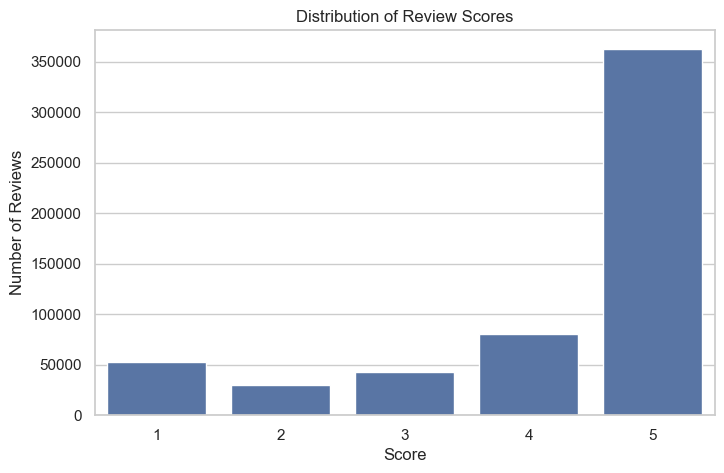

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Score")
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")
plt.show()

We can observe that ratings are mostly high. This suggests that users tend to review products they already like, which is typical on these platforms. Because of this, if almost everything is rated positively, predicting the exact score is less informative, as many items look similar from a rating perspective. What really matters is whether the model can distinguish and rank the best items above the rest and instead of just predicting similar high scores. 

This is why, later valuation should include ranking metrics in addition to regression metrics such as RMSE or MAE.

### 4.2 Reviews over time

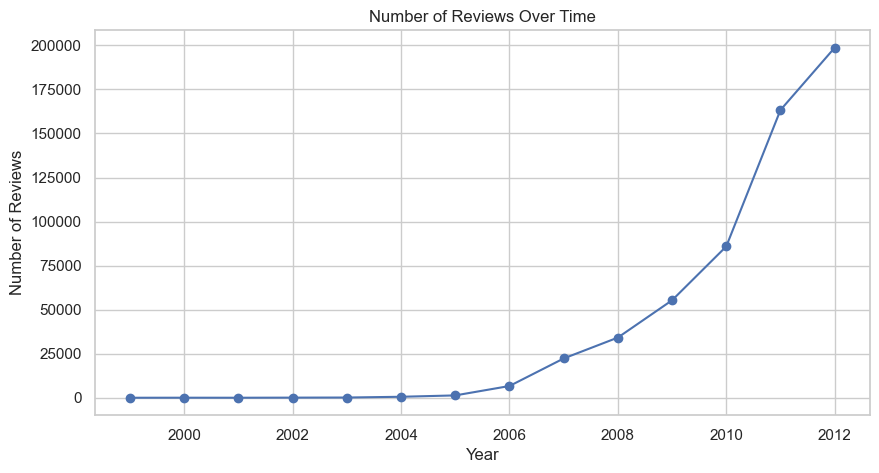

In [12]:
reviews_per_year = df["review_time"].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 5))
reviews_per_year.plot(kind="line", marker="o")
plt.title("Number of Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

Even if we do not build a time aware recommender here, this shows that time can affect and influce results. It also means that random splitting is not the only option and that temporal split would be more realistic since models would need to predict future items based on past interactions.

### 4.3 Long-Tail structure of user and product activity


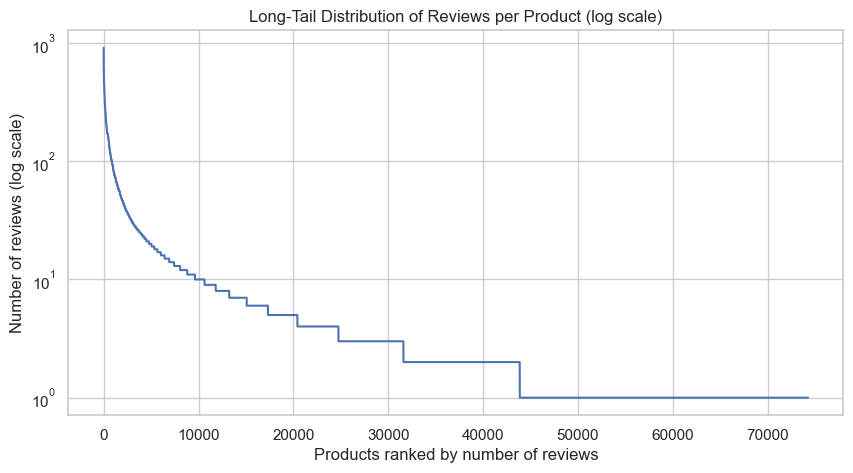

In [13]:
product_review_counts = df.groupby("ProductId").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(range(len(product_review_counts)), product_review_counts.values)
plt.yscale("log")
plt.title("Long-Tail Distribution of Reviews per Product (log scale)")
plt.xlabel("Products ranked by number of reviews")
plt.ylabel("Number of reviews (log scale)")
plt.show()

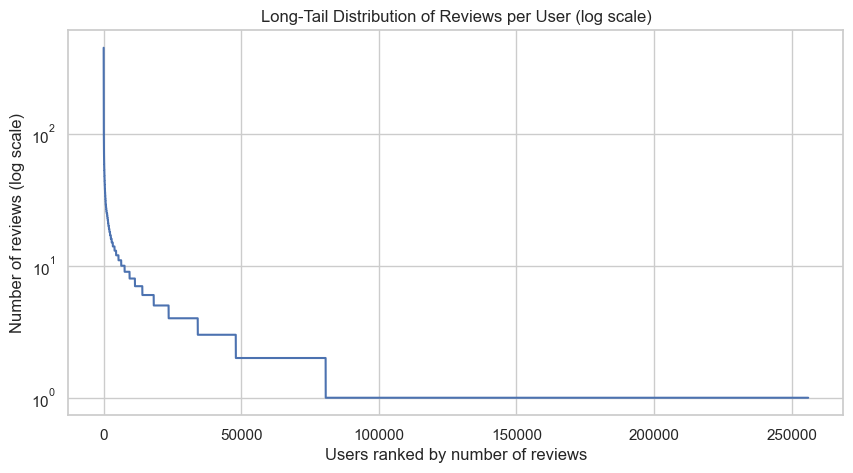

In [14]:
user_review_counts = df.groupby("UserId").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(range(len(user_review_counts)), user_review_counts.values)
plt.yscale("log")
plt.title("Long-Tail Distribution of Reviews per User (log scale)")
plt.xlabel("Users ranked by number of reviews")
plt.ylabel("Number of reviews (log scale)")
plt.show()

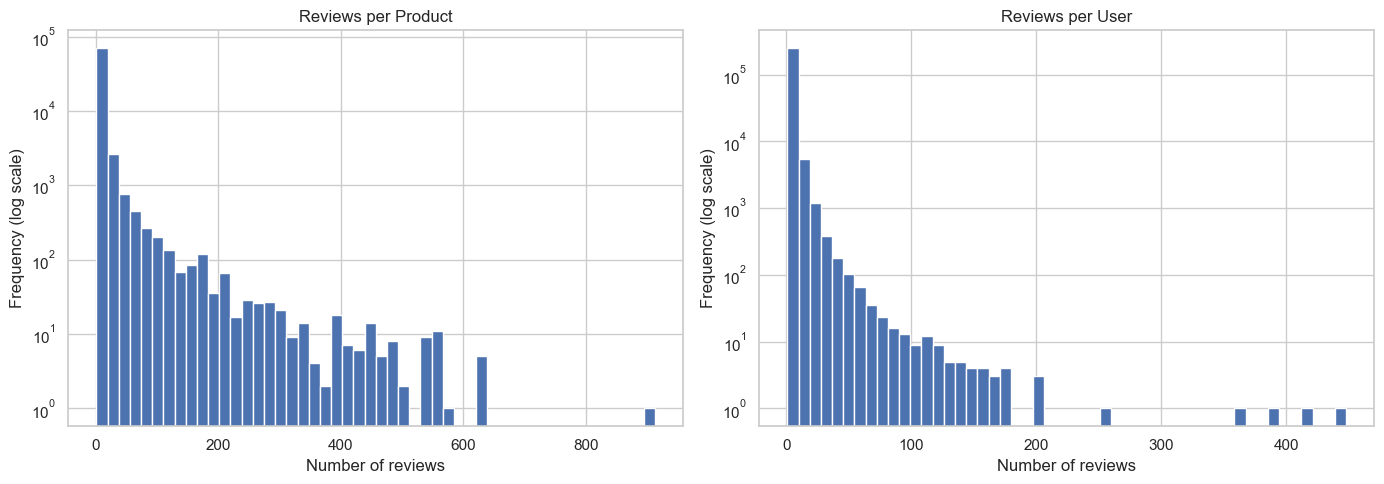

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(product_review_counts.values, bins=50, log=True)
axes[0].set_title("Reviews per Product")
axes[0].set_xlabel("Number of reviews")
axes[0].set_ylabel("Frequency (log scale)")

axes[1].hist(user_review_counts.values, bins=50, log=True)
axes[1].set_title("Reviews per User")
axes[1].set_xlabel("Number of reviews")
axes[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

Both users and products show a clear long tail distribution. A few products get most of the reviews while many receive very little attention. At the same time, a small group of users is very active while most leave only a few reviews.

This creates an uneven recommendation setting, which affects how different recommeders behave. Popularity based methods may perform well on frequently reviewed items just because activity is concetrated around them, but they can end up recommending the same products over and over. At the same time, collaborative filtering becomes harder for many users and items that are in the tail as they have very little data. This is why it's important to compare different types of recommendation methods instead of relying on just one.

### 4.4 Numerical interaction analysis and sparsity

In [16]:
interaction_summary = pd.DataFrame({
    "Metric": [
        "Total reviews",
        "Unique users",
        "Unique products",
        "Average reviews per user",
        "Average reviews per product",
        "Median reviews per user",
        "Median reviews per product"
    ],
    "Value": [
        len(df),
        df["UserId"].nunique(),
        df["ProductId"].nunique(),
        round(df.groupby("UserId").size().mean(), 2),
        round(df.groupby("ProductId").size().mean(), 2),
        int(df.groupby("UserId").size().median()),
        int(df.groupby("ProductId").size().median())
    ]
})

interaction_summary

,Metric,Value
0,Total reviews,568454.00
1,Unique users,256059.00
2,Unique products,74258.00
3,Average reviews per user,2.22
4,Average reviews per product,7.66
5,Median reviews per user,1.00
6,Median reviews per product,2.00


The summary cofirm us that the dataset is very sparse despite its size. We can see that even though it contains 568,454 reviews, these are spread across 256,059 users and 74,258 products. 

On average users have 2.22 reviews while the median is 1, meaning that most users appear only once. For products, the average is 7.66 reviews per product, but the median is 2, so most product also have very little data.

The table confirms again that most users and products have very few interactions and only a small group has many. This means that a good recommender should not only perform well on users or items with lots of data, but also handle cases where very little information is avialable which is actually the case here.

## **5. Recommendation Problem Setup**

### 5.1 Recommendation task definition

We study product recommendation using explicit user feedback in the form of review scores. We consider two related tasks:

- **Rating prediction**: estimate the score a user would give to a product.
- **Top-N recommendation**: rank products so that the most relevant items appear first.

Since the business goal is to improve product display, the ranking task is the most practically important.

### 5.2 Relevance definition

To evaluate ranked recommendations, we need a clear definition of relevance. In this notebook, an interaction is considered **relevant** if the observed review score is **4 or 5**.

This converts the explicit rating signal into a binary relevance signal for ranking evaluation.

## 6. Shared Artifact Export

This notebook is the single source of truth for prepared data and the train/test split used by all recommender notebooks.

Artifacts are saved to `artifacts/shared/` so downstream notebooks can load the same data without recomputing preprocessing.

In [17]:

project_dir = Path.cwd()
shared_dir = project_dir / "artifacts" / "shared"
shared_dir.mkdir(parents=True, exist_ok=True)

# Keep one canonical split for all notebooks.
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

item_metadata = (
    df_model.groupby("ProductId", as_index=False)
    .agg(
        n_reviews=("Score", "size"),
        mean_score=("Score", "mean"),
        mean_helpfulness_ratio=("helpfulness_ratio", "mean"),
        mean_text_length_words=("text_length_words", "mean"),
        latest_review_time=("review_time", "max"),
        full_text=("full_text", lambda s: " ".join(s.dropna().astype(str).head(50)))
    )
)

split_meta = pd.DataFrame(
    [{
        "random_state": 42,
        "test_size": 0.2,
        "min_user_reviews": min_user_reviews,
        "min_product_reviews": min_product_reviews,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "n_users_train": train_df["UserId"].nunique(),
        "n_items_train": train_df["ProductId"].nunique()
    }]
)

df_model.to_csv(shared_dir / "df_model.csv", index=False)
train_df.to_csv(shared_dir / "train_df.csv", index=False)
test_df.to_csv(shared_dir / "test_df.csv", index=False)
item_metadata.to_csv(shared_dir / "item_metadata.csv", index=False)
split_meta.to_csv(shared_dir / "split_meta.csv", index=False)

print("Saved shared artifacts:")
for p in [
    shared_dir / "df_model.csv",
    shared_dir / "train_df.csv",
    shared_dir / "test_df.csv",
    shared_dir / "item_metadata.csv",
    shared_dir / "split_meta.csv",
]:
    print("-", p)

print("\ntrain_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

Saved shared artifacts:
- /Users/silvia/Desktop/BCSAI/Year3/SEM2/RecSys/Recommender-Sys/artifacts/shared/df_model.csv
- /Users/silvia/Desktop/BCSAI/Year3/SEM2/RecSys/Recommender-Sys/artifacts/shared/train_df.csv
- /Users/silvia/Desktop/BCSAI/Year3/SEM2/RecSys/Recommender-Sys/artifacts/shared/test_df.csv
- /Users/silvia/Desktop/BCSAI/Year3/SEM2/RecSys/Recommender-Sys/artifacts/shared/item_metadata.csv
- /Users/silvia/Desktop/BCSAI/Year3/SEM2/RecSys/Recommender-Sys/artifacts/shared/split_meta.csv

train_df shape: (175632, 15)
test_df shape: (43908, 15)
